In [1]:
!pip install requests pandas matplotlib

In [2]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from datetime import datetime

import warnings

warnings.filterwarnings("ignore")

In [3]:
print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
BASE_URL = "https://api.football-data.org/v4"

In [5]:
API_KEY = "a02c4666efd641709046bc62fbfcac76"

In [6]:
headers = {
    "X-Auth-Token": API_KEY
}

In [7]:
def get_data(endpoint):

    url = f"{BASE_URL}/{endpoint}"

    response = requests.get(
        url,
        headers=headers
    )

    print("Status Code :", response.status_code)

    if response.status_code == 200:

        return response.json()

    else:

        print(response.text)

        return None

In [8]:
competitions = get_data("competitions")

Status Code : 200


In [9]:
competitions.keys()

dict_keys(['count', 'filters', 'competitions'])

In [10]:
len(competitions["competitions"])

13

In [11]:
competitions_df = pd.DataFrame(
    competitions["competitions"]
)

In [13]:
competitions_df.head()

,id,area,name,code,type,emblem,plan,currentSeason,numberOfAvailableSeasons,lastUpdated
0,2013,"{'id': 2032, 'name': 'Brazil', 'code': 'BRA', ...",Campeonato Brasileiro Série A,BSA,LEAGUE,https://crests.football-data.org/bsa.png,TIER_ONE,"{'id': 2474, 'startDate': '2026-01-28', 'endDa...",10,2024-09-13T16:55:53Z
1,2016,"{'id': 2072, 'name': 'England', 'code': 'ENG',...",Championship,ELC,LEAGUE,https://crests.football-data.org/ELC.png,TIER_ONE,"{'id': 2509, 'startDate': '2026-08-14', 'endDa...",10,2026-05-11T15:45:39Z
2,2021,"{'id': 2072, 'name': 'England', 'code': 'ENG',...",Premier League,PL,LEAGUE,https://crests.football-data.org/PL.png,TIER_ONE,"{'id': 2502, 'startDate': '2026-08-21', 'endDa...",128,2026-06-19T12:36:02Z
3,2001,"{'id': 2077, 'name': 'Europe', 'code': 'EUR', ...",UEFA Champions League,CL,CUP,https://crests.football-data.org/CL.png,TIER_ONE,"{'id': 2454, 'startDate': '2025-09-16', 'endDa...",46,2026-05-31T11:41:29Z
4,2018,"{'id': 2077, 'name': 'Europe', 'code': 'EUR', ...",European Championship,EC,CUP,https://crests.football-data.org/ec.png,TIER_ONE,"{'id': 1537, 'startDate': '2024-06-14', 'endDa...",17,2024-09-13T17:04:30Z


In [14]:
competitions_df.columns

Index(['id', 'area', 'name', 'code', 'type', 'emblem', 'plan', 'currentSeason',
       'numberOfAvailableSeasons', 'lastUpdated'],
      dtype='object')

In [15]:
competitions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        13 non-null     int64 
 1   area                      13 non-null     object
 2   name                      13 non-null     object
 3   code                      13 non-null     object
 4   type                      13 non-null     object
 5   emblem                    13 non-null     object
 6   plan                      13 non-null     object
 7   currentSeason             13 non-null     object
 8   numberOfAvailableSeasons  13 non-null     int64 
 9   lastUpdated               13 non-null     object
dtypes: int64(2), object(8)
memory usage: 1.1+ KB


In [16]:
competitions_df.describe(include="all")

,id,area,name,code,type,emblem,plan,currentSeason,numberOfAvailableSeasons,lastUpdated
count,13.000000,13,13,13,13,13,13,13,13.000000,13
unique,NaN,11,13,13,2,13,2,13,NaN,13
top,NaN,"{'id': 2072, 'name': 'England', 'code': 'ENG',...",Campeonato Brasileiro Série A,BSA,LEAGUE,https://crests.football-data.org/bsa.png,TIER_ONE,"{'id': 2474, 'startDate': '2026-01-28', 'endDa...",NaN,2024-09-13T16:55:53Z
freq,NaN,2,1,1,9,1,12,1,NaN,1
mean,2022.384615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.769231,NaN
std,39.649587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.923163,NaN
min,2000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN
25%,2003.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000000,NaN
50%,2015.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.000000,NaN
75%,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.000000,NaN


In [17]:
competitions_df[
    competitions_df["name"].str.contains(
        "World",
        case=False,
        na=False
    )
]

,id,area,name,code,type,emblem,plan,currentSeason,numberOfAvailableSeasons,lastUpdated
12,2000,"{'id': 2267, 'name': 'World', 'code': 'INT', '...",FIFA World Cup,WC,CUP,https://crests.football-data.org/wm26.png,TIER_ONE,"{'id': 2398, 'startDate': '2026-06-11', 'endDa...",23,2026-06-24T18:07:13Z


In [18]:
teams = get_data("competitions/WC/teams")

Status Code : 200


In [19]:
teams_df = pd.DataFrame(
    teams["teams"]
)

In [20]:
teams_df.head()

,area,id,name,shortName,tla,crest,address,website,founded,clubColors,venue,runningCompetitions,coach,squad,staff,lastUpdated
0,"{'id': 2257, 'name': 'Uruguay', 'code': 'URY',...",758,Uruguay,Uruguay,URU,https://crests.football-data.org/758.svg,Guayaybo 1531 Montevideo 11200,http://www.auf.org.uy,1900.0,Sky Blue / White / Black,None,"[{'id': 2000, 'name': 'FIFA World Cup', 'code'...","{'id': 56079, 'firstName': 'Marcelo', 'lastNam...","[{'id': 3160, 'name': 'Fernando Muslera', 'pos...",[],2026-06-16T00:37:18Z
1,"{'id': 2088, 'name': 'Germany', 'code': 'DEU',...",759,Germany,Germany,GER,https://crests.football-data.org/759.svg,Otto-Fleck-Schneise 6 / Postfach 710265 Frankf...,http://www.dfb.de,1900.0,White / Black,None,"[{'id': 2000, 'name': 'FIFA World Cup', 'code'...","{'id': 336, 'firstName': 'Julian', 'lastName':...","[{'id': 316, 'name': 'Oliver Baumann', 'positi...",[],2026-06-01T09:41:12Z
2,"{'id': 2224, 'name': 'Spain', 'code': 'ESP', '...",760,Spain,Spain,ESP,https://crests.football-data.org/760.svg,"Ramón y Cajal, s/n Las Rozas 28230",http://www.rfef.es,1909.0,Red / Blue / Yellow,None,"[{'id': 2000, 'name': 'FIFA World Cup', 'code'...","{'id': 192542, 'firstName': 'Luis', 'lastName'...","[{'id': 4832, 'name': 'David Raya', 'position'...",[],2026-06-01T09:41:19Z
3,"{'id': 2183, 'name': 'Paraguay', 'code': 'PRY'...",761,Paraguay,Paraguay,PAR,https://crests.football-data.org/761.svg,Calle Mayor Martínez 1393 Asunción null,http://www.apf.org.py,1906.0,Red / White / Blue,None,"[{'id': 2000, 'name': 'FIFA World Cup', 'code'...","{'id': 45894, 'firstName': 'Gustavo', 'lastNam...","[{'id': 28294, 'name': 'Gastón Olveira', 'posi...",[],2021-05-22T11:35:25Z
4,"{'id': 2011, 'name': 'Argentina', 'code': 'ARG...",762,Argentina,Argentina,ARG,https://crests.football-data.org/762.png,"Viamonte 1366/76 Buenos Aires, Buenos Aires 1053",http://www.afa.org.ar,1893.0,Sky Blue / White / Black,None,"[{'id': 2000, 'name': 'FIFA World Cup', 'code'...","{'id': 82990, 'firstName': 'Lionel', 'lastName...","[{'id': 6, 'name': 'Géronimo Rulli', 'position...",[],2022-05-17T21:09:25Z


In [21]:
print(len(teams_df))

48


In [22]:
teams_df.columns

Index(['area', 'id', 'name', 'shortName', 'tla', 'crest', 'address', 'website',
       'founded', 'clubColors', 'venue', 'runningCompetitions', 'coach',
       'squad', 'staff', 'lastUpdated'],
      dtype='object')

In [23]:
matches = get_data("competitions/WC/matches")

Status Code : 200


In [24]:
matches_df = pd.json_normalize(
    matches["matches"]
)

In [25]:
matches_df.head()

,id,utcDate,status,matchday,stage,group,lastUpdated,referees,area.id,area.name,...,score.fullTime.away,score.halfTime.home,score.halfTime.away,odds.msg,score.regularTime.home,score.regularTime.away,score.extraTime.home,score.extraTime.away,score.penalties.home,score.penalties.away
0,537327,2026-06-11T19:00:00Z,FINISHED,1.0,GROUP_STAGE,GROUP_A,2026-07-03T15:20:13Z,"[{'id': 11412, 'name': 'Wilton Sampaio', 'type...",2267,World,...,0.0,1.0,0.0,Activate Odds-Package in User-Panel to retriev...,NaN,NaN,NaN,NaN,NaN,NaN
1,537328,2026-06-12T02:00:00Z,FINISHED,1.0,GROUP_STAGE,GROUP_A,2026-07-03T15:20:13Z,"[{'id': 276653, 'name': 'Amin Omar', 'type': '...",2267,World,...,1.0,0.0,0.0,Activate Odds-Package in User-Panel to retriev...,NaN,NaN,NaN,NaN,NaN,NaN
2,537333,2026-06-12T19:00:00Z,FINISHED,1.0,GROUP_STAGE,GROUP_B,2026-07-03T15:20:13Z,"[{'id': 57301, 'name': 'Facundo Tello', 'type'...",2267,World,...,1.0,0.0,1.0,Activate Odds-Package in User-Panel to retriev...,NaN,NaN,NaN,NaN,NaN,NaN
3,537345,2026-06-13T01:00:00Z,FINISHED,1.0,GROUP_STAGE,GROUP_D,2026-07-03T15:20:13Z,"[{'id': 43899, 'name': 'Danny Makkelie', 'type...",2267,World,...,1.0,3.0,0.0,Activate Odds-Package in User-Panel to retriev...,NaN,NaN,NaN,NaN,NaN,NaN
4,537334,2026-06-13T19:00:00Z,FINISHED,1.0,GROUP_STAGE,GROUP_B,2026-07-03T15:20:13Z,"[{'id': 190002, 'name': 'Said Martinez', 'type...",2267,World,...,1.0,0.0,1.0,Activate Odds-Package in User-Panel to retriev...,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
matches_df.shape

(104, 45)

In [27]:
matches_df.columns

Index(['id', 'utcDate', 'status', 'matchday', 'stage', 'group', 'lastUpdated',
       'referees', 'area.id', 'area.name', 'area.code', 'area.flag',
       'competition.id', 'competition.name', 'competition.code',
       'competition.type', 'competition.emblem', 'season.id',
       'season.startDate', 'season.endDate', 'season.currentMatchday',
       'season.winner', 'homeTeam.id', 'homeTeam.name', 'homeTeam.shortName',
       'homeTeam.tla', 'homeTeam.crest', 'awayTeam.id', 'awayTeam.name',
       'awayTeam.shortName', 'awayTeam.tla', 'awayTeam.crest', 'score.winner',
       'score.duration', 'score.fullTime.home', 'score.fullTime.away',
       'score.halfTime.home', 'score.halfTime.away', 'odds.msg',
       'score.regularTime.home', 'score.regularTime.away',
       'score.extraTime.home', 'score.extraTime.away', 'score.penalties.home',
       'score.penalties.away'],
      dtype='object')

In [28]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      104 non-null    int64  
 1   utcDate                 104 non-null    object 
 2   status                  104 non-null    object 
 3   matchday                72 non-null     float64
 4   stage                   104 non-null    object 
 5   group                   72 non-null     object 
 6   lastUpdated             104 non-null    object 
 7   referees                104 non-null    object 
 8   area.id                 104 non-null    int64  
 9   area.name               104 non-null    object 
 10  area.code               104 non-null    object 
 11  area.flag               0 non-null      object 
 12  competition.id          104 non-null    int64  
 13  competition.name        104 non-null    object 
 14  competition.code        104 non-null    ob

In [29]:
matches_df.isnull().sum()

,0
id,0
utcDate,0
status,0
matchday,32
stage,0
group,32
lastUpdated,0
referees,0
area.id,0
area.name,0


In [30]:
matches_df = matches_df.drop(
    columns=[
        "area.id",
        "competition.id"
    ],
    errors="ignore"
)

In [31]:
matches_df["utcDate"] = pd.to_datetime(
    matches_df["utcDate"]
)

In [32]:
matches_df["year"] = matches_df["utcDate"].dt.year

In [33]:
matches_df["month"] = matches_df["utcDate"].dt.month

In [35]:
print(matches_df.columns.tolist())

['id', 'utcDate', 'status', 'matchday', 'stage', 'group', 'lastUpdated', 'referees', 'area.name', 'area.code', 'area.flag', 'competition.name', 'competition.code', 'competition.type', 'competition.emblem', 'season.id', 'season.startDate', 'season.endDate', 'season.currentMatchday', 'season.winner', 'homeTeam.id', 'homeTeam.name', 'homeTeam.shortName', 'homeTeam.tla', 'homeTeam.crest', 'awayTeam.id', 'awayTeam.name', 'awayTeam.shortName', 'awayTeam.tla', 'awayTeam.crest', 'score.winner', 'score.duration', 'score.fullTime.home', 'score.fullTime.away', 'score.halfTime.home', 'score.halfTime.away', 'odds.msg', 'score.regularTime.home', 'score.regularTime.away', 'score.extraTime.home', 'score.extraTime.away', 'score.penalties.home', 'score.penalties.away', 'year', 'month']


In [36]:
matches_df["year"].value_counts().sort_index()

,count
year,
2026,104


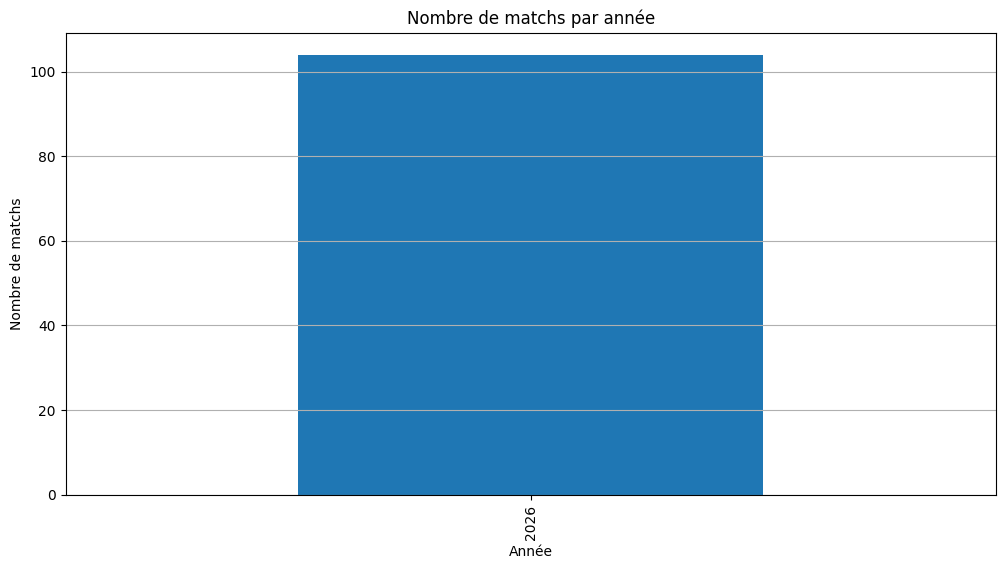

In [37]:
plt.figure(figsize=(12,6))

matches_df["year"].value_counts().sort_index().plot(kind="bar")

plt.title("Nombre de matchs par année")

plt.xlabel("Année")

plt.ylabel("Nombre de matchs")

plt.grid(axis="y")

plt.show()

In [38]:
matches_df["stage"].value_counts()

,count
stage,
GROUP_STAGE,72
LAST_32,16
LAST_16,8
QUARTER_FINALS,4
SEMI_FINALS,2
THIRD_PLACE,1
FINAL,1


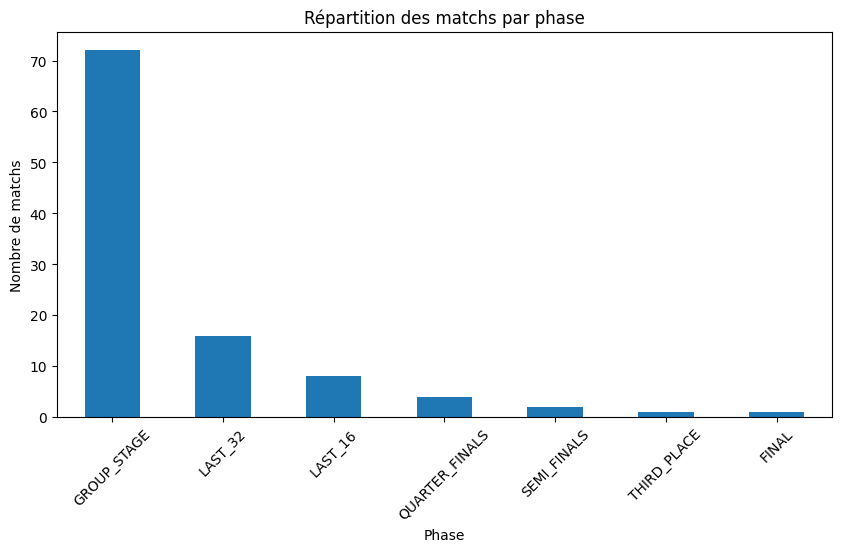

In [39]:
plt.figure(figsize=(10,5))

matches_df["stage"].value_counts().plot(kind="bar")

plt.title("Répartition des matchs par phase")

plt.xlabel("Phase")

plt.ylabel("Nombre de matchs")

plt.xticks(rotation=45)

plt.show()

In [40]:
matches_df["status"].value_counts()

,count
status,
FINISHED,89
TIMED,14
LIVE,1


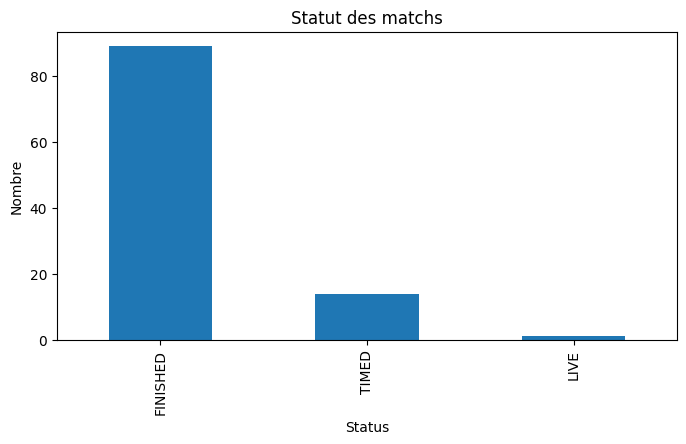

In [41]:
plt.figure(figsize=(8,4))

matches_df["status"].value_counts().plot(kind="bar")

plt.title("Statut des matchs")

plt.xlabel("Status")

plt.ylabel("Nombre")

plt.show()

In [42]:
matches_df.isnull().sum().sort_values(ascending=False)

,0
area.flag,104
season.winner,104
score.penalties.home,101
score.penalties.away,101
score.regularTime.away,99
score.extraTime.home,99
score.extraTime.away,99
score.regularTime.home,99
group,32
matchday,32


In [44]:
import os

# Créer le dossier data/raw s'il n'existe pas
os.makedirs("data/raw", exist_ok=True)

print("Dossier créé avec succès !")

Dossier créé avec succès !


In [45]:
os.listdir("data")

['raw']

In [46]:
competitions_df.to_csv(
    "data/raw/competitions.csv",
    index=False
)

teams_df.to_csv(
    "data/raw/teams.csv",
    index=False
)

matches_df.to_csv(
    "data/raw/matches.csv",
    index=False
)